In [13]:
# Import the necessary modules 
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from nltk.stem import WordNetLemmatizer
from nltk.util import ngrams
from gensim.parsing.preprocessing import STOPWORDS

root_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
reports_dir = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'reports')
figures_dir = os.path.join(reports_dir, 'figures')
tables_dir = os.path.join(reports_dir, 'tables')
os.makedirs(figures_dir, exist_ok=True)
os.makedirs(tables_dir, exist_ok=True)
print(f"Figures will be saved to: {figures_dir}")
print(f"Tables will be saved to: {tables_dir}")


Figures will be saved to: e:\Study\Bristol\IATA\Group_Project\Final\EMATM0067_2025_TB-2-g43\notebooks\01_eda\reports\figures
Tables will be saved to: e:\Study\Bristol\IATA\Group_Project\Final\EMATM0067_2025_TB-2-g43\notebooks\01_eda\reports\tables


In [14]:
#### updated the code to access the file from local - THIRUVEL 
#### df = pd.read_csv("data/raw/customer_support_tickets.csv", encoding='utf-8')
#### print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
#### df.head()

### actual code
# download_path = kagglehub.dataset_download("suraj520/customer-support-ticket-dataset")
# csv_path = os.path.join(download_path, "customer_support_tickets.csv")
# df = pd.read_csv(csv_path, encoding='utf-8')
# print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
# df.head()

In [15]:
#### Read data from /data/raw/customer_support_tickets.csv - ZHAOQI
current_dir = os.getcwd()

if "notebooks" in current_dir:
    root_path = current_dir.split("notebooks")[0] 
else:
    root_path = current_dir

csv_path = os.path.join(root_path, "data", "raw", "customer_support_tickets.csv")

print(f"{csv_path}")

df = pd.read_csv(csv_path, encoding='utf-8')
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
display(df.head())


e:\Study\Bristol\IATA\Group_Project\Final\EMATM0067_2025_TB-2-g43\data\raw\customer_support_tickets.csv
Dataset: 8469 rows, 17 columns


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


Saved figure: eda_fahmi_fig_2.png


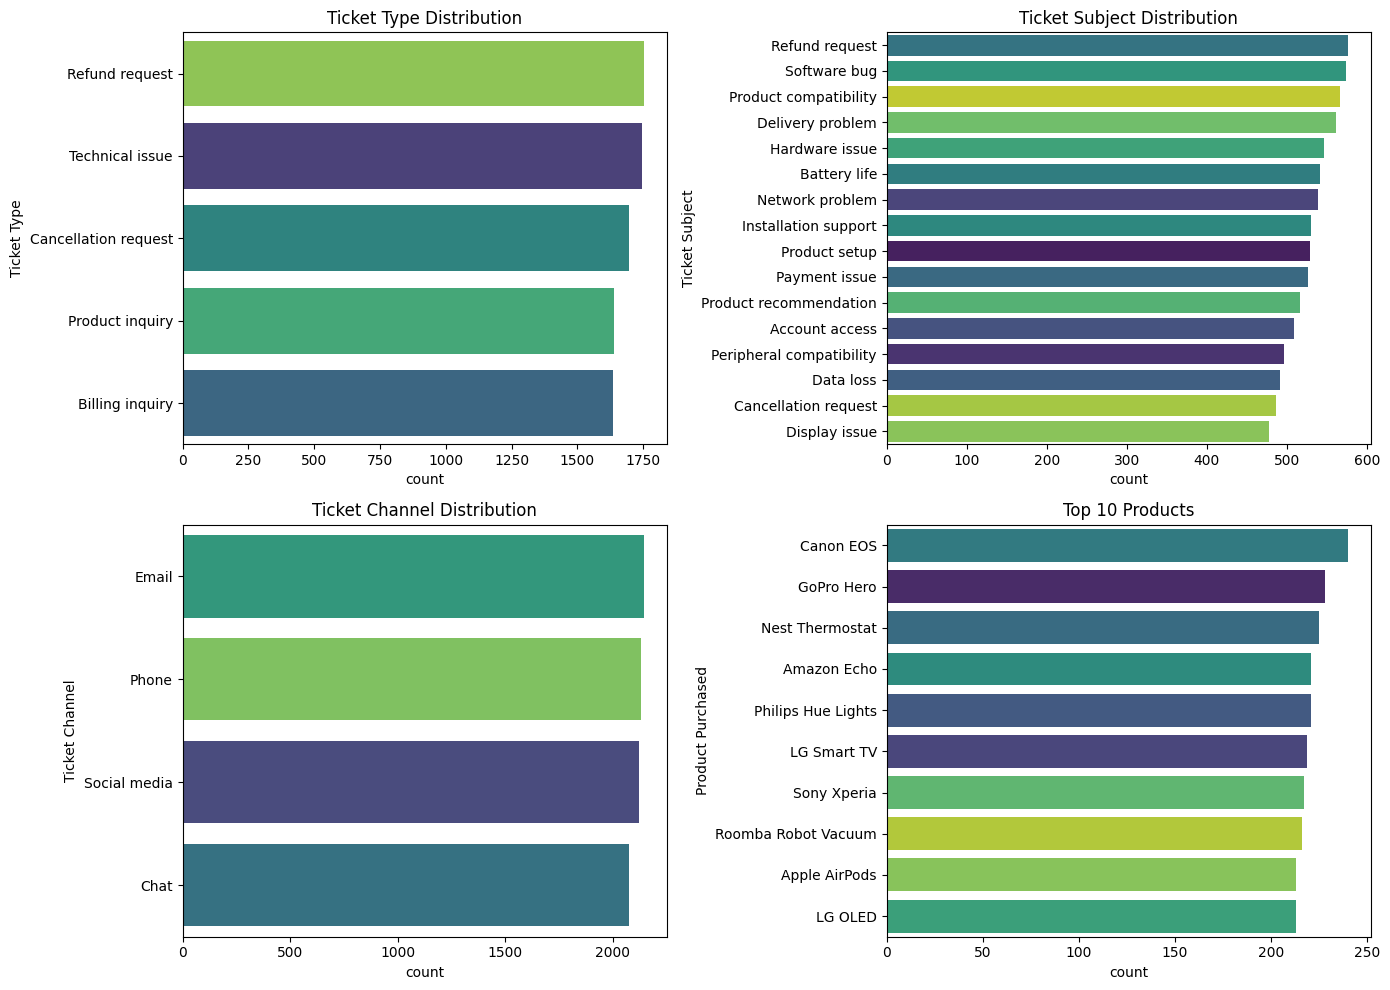

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.countplot(data=df, y='Ticket Type', order=df['Ticket Type'].value_counts().index,
              hue='Ticket Type', legend=False, palette='viridis', ax=axes[0,0])
axes[0,0].set_title('Ticket Type Distribution')
sns.countplot(data=df, y='Ticket Subject', order=df['Ticket Subject'].value_counts().index,
              hue='Ticket Subject', legend=False, palette='viridis', ax=axes[0,1])
axes[0,1].set_title('Ticket Subject Distribution')
sns.countplot(data=df, y='Ticket Channel', order=df['Ticket Channel'].value_counts().index,
              hue='Ticket Channel', legend=False, palette='viridis', ax=axes[1,0])
axes[1,0].set_title('Ticket Channel Distribution')
top_products = df['Product Purchased'].value_counts().head(10).index
sns.countplot(data=df[df['Product Purchased'].isin(top_products)], y='Product Purchased',
              order=top_products, hue='Product Purchased', legend=False, palette='viridis', ax=axes[1,1])
axes[1,1].set_title('Top 10 Products')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'eda_fahmi_ticket_distributions.png'), dpi=300, bbox_inches='tight')

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'eda_fahmi_fig_2.png'), dpi=300, bbox_inches='tight')
print(f"Saved figure: eda_fahmi_fig_2.png")

plt.show()

In [17]:
print("=== Ticket Description Corpus Stats ===")
df['word_count'] = df['Ticket Description'].str.split().str.len()
print(f"Total tickets: {len(df)}")
print(f"Mean word count: {df['word_count'].mean():.1f}")
print(f"Template placeholders: {df['Ticket Description'].str.contains('{').sum()} / {len(df)} (100%)")
### This can't work in my env :(
# print(f"Social media handles: {df['Ticket Description'].str.contains(r'@\w+', regex=True).sum()}")
### Replace with this one - ZHAOQI
handle_count = df['Ticket Description'].str.contains(r'@\w+', regex=True).sum()
print(f"Social media handles: {handle_count}")

print(f"Missing Resolution: {df['Resolution'].isnull().sum()} ({df['Resolution'].isnull().mean()*100:.1f}%)")
print("\n=== Cross-tab: Ticket Type vs Priority ===")
print(pd.crosstab(df['Ticket Type'], df['Ticket Priority']))

=== Ticket Description Corpus Stats ===
Total tickets: 8469
Mean word count: 46.5
Template placeholders: 8469 / 8469 (100%)
Social media handles: 203
Missing Resolution: 5700 (67.3%)

=== Cross-tab: Ticket Type vs Priority ===
Ticket Priority       Critical  High  Low  Medium
Ticket Type                                      
Billing inquiry            420   382  398     434
Cancellation request       423   398  414     460
Product inquiry            403   399  398     441
Refund request             444   448  440     420
Technical issue            439   458  413     437


In [18]:
print("=== Sample Ticket Descriptions ===\n")
for i in range(5):
    print(f"--- Ticket {i} (Type: {df['Ticket Type'].iloc[i]}) ---")
    print(df['Ticket Description'].iloc[i][:300])
    print()

=== Sample Ticket Descriptions ===

--- Ticket 0 (Type: Technical issue) ---
I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.

--- Ticket 1 (Type: Technical issue) ---
I'm having an issue with the {product_purchased}. Please assist.

If you need to change an existing product.

I'm having an issue with the {product_purchased}. Please assist.

If The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.

--- Ticket 2 (Type: Technical issue) ---
I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond.

1.8.3 I really I'm using the original charger that came with my {product_purchased}, but it's not charging prope

In [19]:
def get_top_ngrams(df, ticket_type, n=2, top_k=8):
    texts = ' '.join(df[df['Ticket Type'] == ticket_type]['Ticket Description']).lower().split()
    return Counter(ngrams(texts, n)).most_common(top_k)

print("=== Top Bigrams by Ticket Type (Raw Text) ===")
for tt in df['Ticket Type'].unique():
    bigrams = get_top_ngrams(df, tt, n=2, top_k=5)
    formatted = [(' '.join(bg), c) for bg, c in bigrams]
    print(f"{tt:25s} Ã¢â€ â€™ {formatted}")

=== Top Bigrams by Ticket Type (Raw Text) ===
Technical issue           Ã¢â€ â€™ [('the {product_purchased}.', 1432), ('with the', 1338), ('issue with', 1330), ("i'm having", 1318), ('an issue', 1307)]
Billing inquiry           Ã¢â€ â€™ [('the {product_purchased}.', 1295), ('with the', 1250), ('issue with', 1227), ("i'm having", 1212), ('an issue', 1207)]
Cancellation request      Ã¢â€ â€™ [('the {product_purchased}.', 1351), ('with the', 1287), ('issue with', 1281), ("i'm having", 1278), ('an issue', 1257)]
Product inquiry           Ã¢â€ â€™ [('the {product_purchased}.', 1295), ('issue with', 1234), ('with the', 1219), ("i'm having", 1212), ('an issue', 1195)]
Refund request            Ã¢â€ â€™ [('the {product_purchased}.', 1390), ('issue with', 1322), ('with the', 1310), ("i'm having", 1302), ('an issue', 1293)]
